<a href="https://colab.research.google.com/github/ArjnCrly/PCVK_Genap_2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

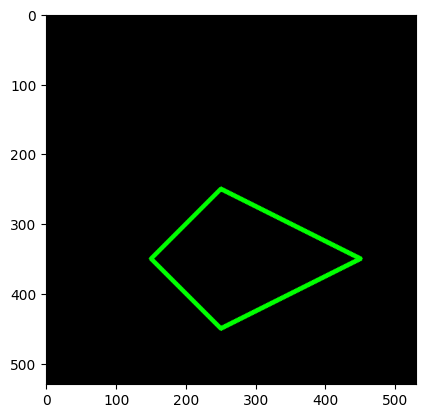

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
vertices = np.array([[(150, 350), (250, 250), (450, 350), (250,450)]], dtype=np.int32)

pts = vertices.reshape((-1, 1, 2))


cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)
plt.imshow(black_img2)

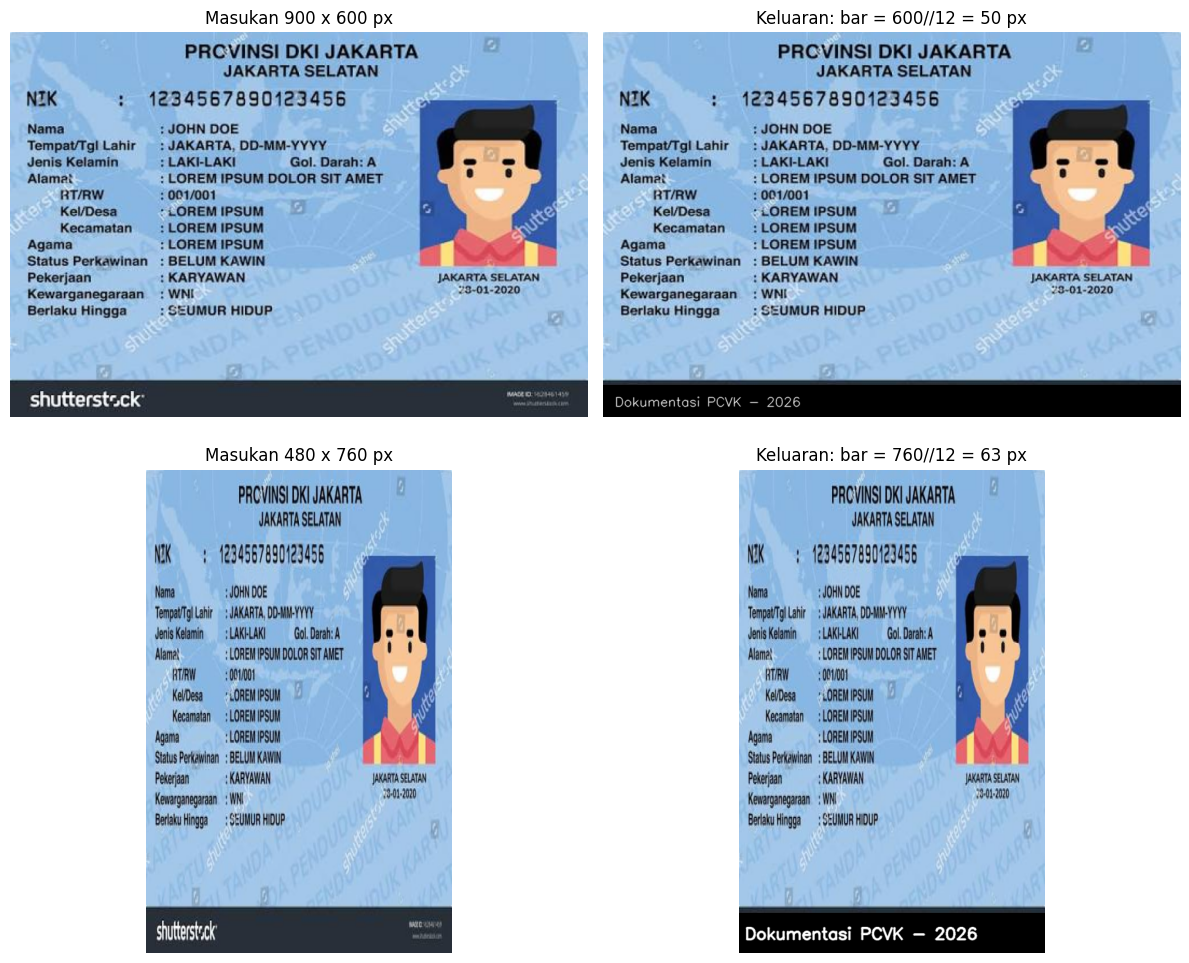

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def beri_label_adaptif(citra, teks="Dokumentasi PCVK - 2026"):
    img = citra.copy()
    h, w = img.shape[:2]

    bar_height = h // 12

    img[h - bar_height : h, 0 : w] = (0, 0, 0)

    font_scale = bar_height / 75.0
    thickness = max(1, int(round(font_scale * 2.2)))

    (text_w, text_h), baseline = cv.getTextSize(
        teks, cv.FONT_HERSHEY_SIMPLEX, font_scale, thickness
    )

    text_x = int(w * 0.02)

    text_y = h - (bar_height - text_h) //

    cv.putText(
        img,
        text=teks,
        org=(text_x, text_y),
        fontFace=cv.FONT_HERSHEY_SIMPLEX,
        fontScale=font_scale,
        color=(255, 255, 255),
        thickness=thickness,
        lineType=cv.LINE_AA
    )

    return img, bar_height

citra_uji = cv.imread('/content/drive/MyDrive/PCVK/ktp.jpg')

if citra_uji is not None:
    citra_uji_rgb = cv.cvtColor(citra_uji, cv.COLOR_BGR2RGB)
    img_lanskap = cv.resize(citra_uji_rgb, (900, 600), interpolation=cv.INTER_AREA)
    img_potret  = cv.resize(citra_uji_rgb, (480, 760), interpolation=cv.INTER_AREA)
else:
    img_lanskap = np.full((600, 900, 3), (85, 130, 175), dtype=np.uint8)
    img_potret  = np.full((760, 480, 3), (85, 130, 175), dtype=np.uint8)

hasil_lanskap, bar_l = beri_label_adaptif(img_lanskap)
hasil_potret, bar_p  = beri_label_adaptif(img_potret)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_lanskap)
axes[0, 0].set_title(f"Masukan {img_lanskap.shape[1]} x {img_lanskap.shape[0]} px")
axes[0, 0].axis('off')

axes[0, 1].imshow(hasil_lanskap)
axes[0, 1].set_title(f"Keluaran: bar = {img_lanskap.shape[0]}//12 = {bar_l} px")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_potret)
axes[1, 0].set_title(f"Masukan {img_potret.shape[1]} x {img_potret.shape[0]} px")
axes[1, 0].axis('off')

axes[1, 1].imshow(hasil_potret)
axes[1, 1].set_title(f"Keluaran: bar = {img_potret.shape[0]}//12 = {bar_p} px")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

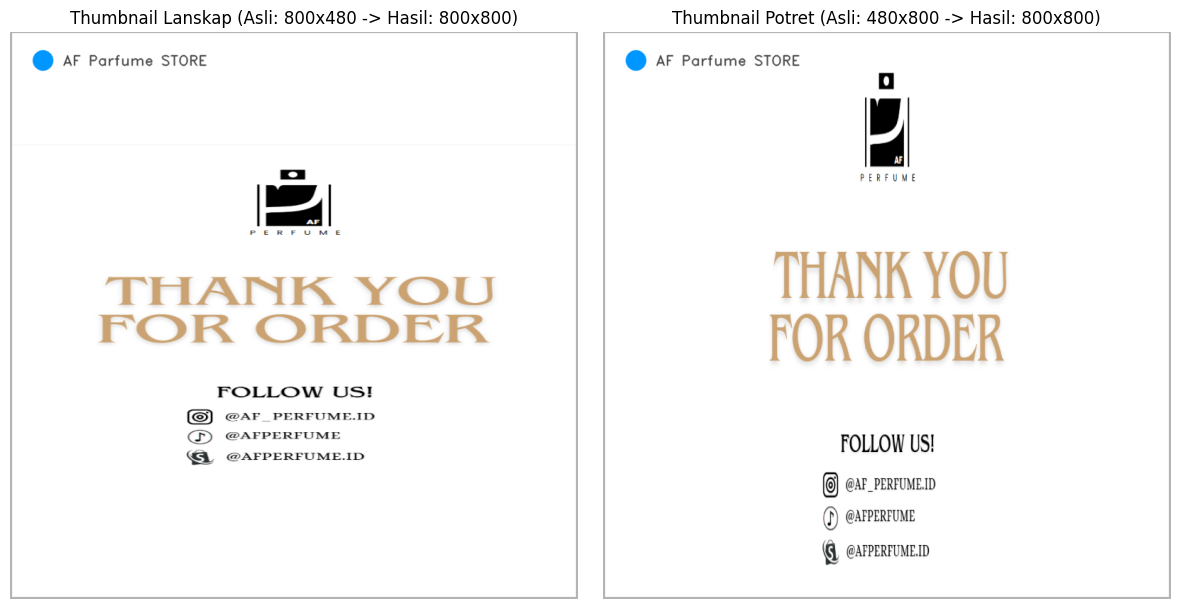

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def buat_thumbnail_marketplace(citra, nama_toko="AF Parfume STORE", warna_kanvas=(255, 255, 255)):
    """
    Mengubah citra orientasi apa pun menjadi bingkai persegi 1:1 adaptif.
    - Sisa ruang diisi kanvas berwarna (default: putih).
    - Citra diposisikan persis di tengah (letterboxing/pillarboxing).
    - Menambahkan logo/nama toko dengan ukuran dan posisi proporsional.
    """
    h, w = citra.shape[:2]

    sisi_persegi = max(h, w)

    thumbnail = np.full((sisi_persegi, sisi_persegi, 3), warna_kanvas, dtype=np.uint8)

    y_offset = (sisi_persegi - h) // 2
    x_offset = (sisi_persegi - w) // 2

    thumbnail[y_offset : y_offset + h, x_offset : x_offset + w] = citra

    tebal_border = max(1, int(sisi_persegi * 0.005))
    cv.rectangle(thumbnail, (0, 0), (sisi_persegi - 1, sisi_persegi - 1),
                 (180, 180, 180), thickness=tebal_border)

    font_scale = sisi_persegi / 1200.0
    thickness_font = max(1, int(round(font_scale * 2.2)))

    margin_x = int(sisi_persegi * 0.04)
    margin_y = int(sisi_persegi * 0.06)

    radius_logo = int(sisi_persegi * 0.018)
    center_logo = (margin_x + radius_logo, margin_y - radius_logo // 2)
    cv.circle(thumbnail, center_logo, radius_logo, (0, 150, 255), thickness=-1, lineType=cv.LINE_AA)

    pos_teks = (margin_x + radius_logo * 3, margin_y)
    cv.putText(thumbnail, nama_toko, pos_teks, cv.FONT_HERSHEY_DUPLEX,
               font_scale, (70, 70, 70), thickness=thickness_font, lineType=cv.LINE_AA)

    return thumbnail

citra_asli = cv.imread('/content/drive/MyDrive/PCVK/Screenshot 2025-03-04 225429.png')

if citra_asli is not None:
    citra_rgb = cv.cvtColor(citra_asli, cv.COLOR_BGR2RGB)
    citra_lanskap = cv.resize(citra_rgb, (800, 480), interpolation=cv.INTER_AREA)
    citra_potret  = cv.resize(citra_rgb, (480, 800), interpolation=cv.INTER_AREA)
else:
    citra_lanskap = np.full((480, 800, 3), (85, 130, 175), dtype=np.uint8)
    citra_potret  = np.full((800, 480, 3), (85, 130, 175), dtype=np.uint8)

thumb_lanskap = buat_thumbnail_marketplace(citra_lanskap, nama_toko="AF Parfume STORE")
thumb_potret  = buat_thumbnail_marketplace(citra_potret,  nama_toko="AF Parfume STORE")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(thumb_lanskap)
axes[0].set_title(f"Thumbnail Lanskap (Asli: 800x480 -> Hasil: {thumb_lanskap.shape[1]}x{thumb_lanskap.shape[0]})")
axes[0].axis('off')

axes[1].imshow(thumb_potret)
axes[1].set_title(f"Thumbnail Potret (Asli: 480x800 -> Hasil: {thumb_potret.shape[1]}x{thumb_potret.shape[0]})")
axes[1].axis('off')

plt.tight_layout()
plt.show()